<a href="https://colab.research.google.com/github/DevGaonkar/project-0/blob/main/AIDS_Exp1A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 104.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

In [ ]:
# Define Bayesian Network structure
model = DiscreteBayesianNetwork([('Guest', 'Host'), ('Price', 'Host')])

# Define CPDs
cpd_guest = TabularCPD('Guest', 3, [[0.33], [0.33], [0.34]])
cpd_price = TabularCPD('Price', 3, [[0.33], [0.33], [0.34]])
cpd_host = TabularCPD(
    variable='Host',
    variable_card=3,
    values=[
        [0, 0, 0, 0, 0.5, 1, 0, 1, 0.5],
        [0.5, 0, 1, 0, 0, 0, 1, 0, 0.5],
        [0.5, 1, 0, 1, 0.5, 0, 0, 0, 0]
    ],
    evidence=['Guest', 'Price'],
    evidence_card=[3, 3]
)

In [ ]:
#Associating the CPDs with the network structure.
model.add_cpds(cpd_guest, cpd_price, cpd_host)
model.check_model()

True

In [ ]:
from pgmpy.inference import VariableElimination
infer = VariableElimination(model)
posterior_p = infer.query(['Host'], evidence={'Guest': 2, 'Price': 2})
print(posterior_p)

+---------+-------------+
| Host    |   phi(Host) |
+=========+=============+
| Host(0) |      0.5000 |
+---------+-------------+
| Host(1) |      0.5000 |
+---------+-------------+
| Host(2) |      0.0000 |
+---------+-------------+


In [ ]:
from pgmpy.inference import VariableElimination
infer = VariableElimination(model)
posterior_p = infer.query(['Host'], evidence={'Guest': 1, 'Price': 2})
print(posterior_p)

+---------+-------------+
| Host    |   phi(Host) |
+=========+=============+
| Host(0) |      1.0000 |
+---------+-------------+
| Host(1) |      0.0000 |
+---------+-------------+
| Host(2) |      0.0000 |
+---------+-------------+


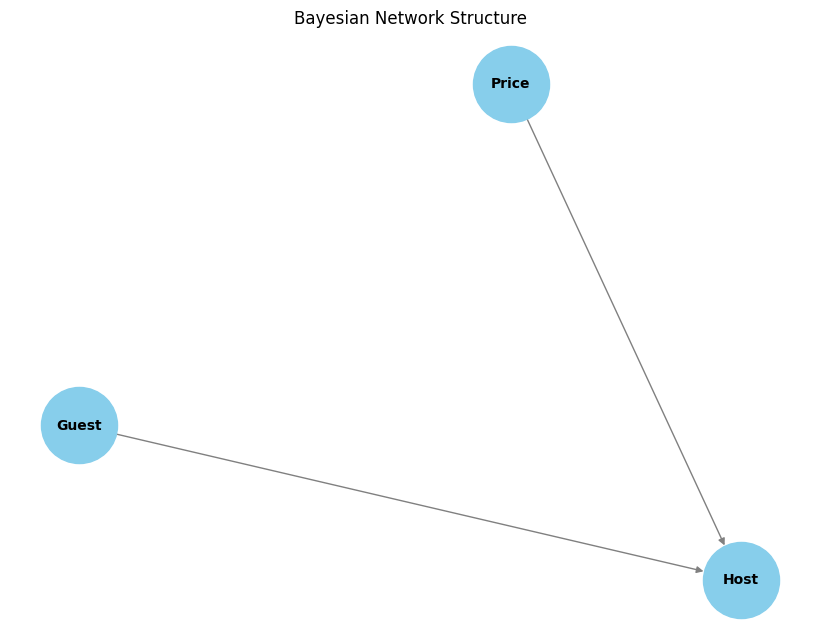

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Access the internal graph structure of the model
edges = model.edges()

# Create a NetworkX DiGraph from the edges
nx_graph = nx.DiGraph(edges)

# Draw the graph using NetworkX
plt.figure(figsize=(8, 6))
nx.draw(nx_graph, with_labels=True, node_size=3000, node_color="skyblue", font_size=10, font_weight='bold', edge_color="gray")
plt.title("Bayesian Network Structure")
plt.show()